### 1. `data_generators.py` (Module Sinh dữ liệu)
* **Uniform i.i.d:** Phân bố đều trong khoảng $[-\sqrt{3}, \sqrt{3}]$ để chuẩn hóa $SD=1$.
* **MIX($p$):** 
  * Tín hiệu tất định: $x_j = \sin(2\pi j / 12)$
  * Tín hiệu nhiễu: $y_j \sim \text{Uniform}[-\sqrt{3}, \sqrt{3}]$
  * Đầu ra: $\text{MIX}(p) = (1 - z_j)x_j + z_j y_j$ (với $z_j=1$ theo xác suất $p$).

### 2. `exp1_bias_variance.py` (Độ lệch & Phương sai - Hình 1, 2)
* **Mục tiêu:** So sánh ApEn/SampEn với lý thuyết nhiễu trắng: $H(r) = -\ln(r) - \ln(2)$.
* **Khảo sát $r$:** Dải log $[0.01, 1.0]$ trên các mốc $N \in \{100, 1000, 5000, 20000\}$.
* **Khảo sát $N$:** Dùng thông số $A, B$ từ `sampen(verbose=True)` tính Variance, vẽ khoảng tin cậy (Confidence Intervals) 95%.

### 3. `exp2_consistency.py` (Tính nhất quán - Hình 3A, 3B)
* **Cấu hình:** 10 chuỗi MIX($0.1$) và 10 chuỗi MIX($0.9$) với $N=1000$.
* **Thực thi:** Khảo sát ApEn/SampEn trên dải $r$ logarithmic.
* **Kỳ vọng:** Đồ thị ApEn bị lỗi giao cắt (cross-over) tại $r < 0.05$. Đồ thị SampEn song song tuyệt đối.

### 4. `exp3_deep_limits.py` (Giới hạn sâu - Hình 3C)
* **Monte Carlo:** Chạy $10^5$ realizations cho $N$ siêu ngắn ($4 \le N \le 100$). Tăng tốc bằng `joblib`/`multiprocessing`.
* **Disjoint vs Overlapping:**
  * Viết hàm mini so sánh các cặp vector *tách rời* (dùng `x.reshape(-1, m)`) vs *gối đầu*.
  * **Kỳ vọng:** Phương pháp disjoint đạt ~0.111 (chứng minh sai số dư sinh ra hoàn toàn do đặc tính chồng lấp vector).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from typing import Optional
sys.path.append(os.path.abspath(".."))
from core_ntsa.apen import approx_entropy
from core_ntsa.sampen import sampen

# 1. DATA GENERATION

--- Statistical Sanity Checks (Expected: Mean ~ 0, Std ~ 1) ---
Uniform i.i.d   | Mean:  0.002 | Std:  0.999 | Var:  0.999
Gaussian i.i.d  | Mean: -0.004 | Std:  1.004 | Var:  1.007
MIX(0.1)        | Mean:  0.001 | Std:  0.999 | Var:  0.998
MIX(0.9)        | Mean:  0.001 | Std:  1.001 | Var:  1.001
-----------------------------------------------------------------


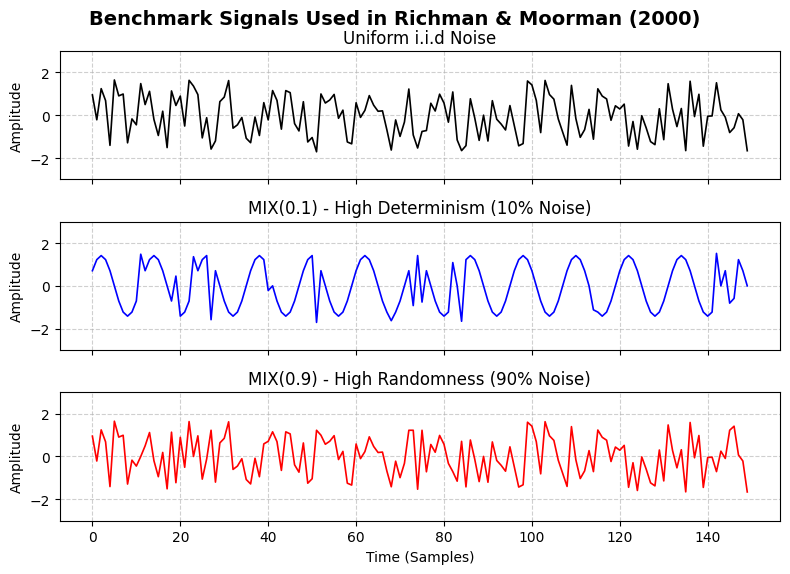

In [5]:
def generate_uniform_iid(n_samples: int, seed: Optional[int] = None) -> np.ndarray:
    """
    Generate i.i.d uniform noise.
    Bounds [-sqrt(3), sqrt(3)] ensure Variance = 1, SD = 1.
    """
    rng = np.random.default_rng(seed)
    bound = np.sqrt(3)
    return rng.uniform(-bound, bound, n_samples)


def generate_gaussian_iid(n_samples: int, seed: Optional[int] = None) -> np.ndarray:
    """
    Generate i.i.d Gaussian noise.
    Mean = 0, SD = 1 for Deep Limits experiment (Exp 3).
    """
    rng = np.random.default_rng(seed)
    return rng.normal(0, 1, n_samples)


def generate_logistic_map(r: float, x0: float, n_samples: int) -> np.ndarray:
    """
    Generate time series from the Logistic Map: x_{n+1} = r * x_n * (1 - x_n).
    Useful for testing true deterministic chaos.
    """
    x = np.empty(n_samples)
    x[0] = x0
    for i in range(1, n_samples):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x


def generate_mix_p(p: float, n_samples: int, seed: Optional[int] = None) -> np.ndarray:
    """
    Generate MIX(p) time series introduced by Pincus.
    Combines deterministic sine wave and stochastic uniform noise.
    """
    rng = np.random.default_rng(seed)
    
    # Deterministic component: periodic sine wave scaled by sqrt(2) 
    # to ensure its Variance is 1, matching the noise component.
    j = np.arange(1, n_samples + 1)
    x = np.sqrt(2) * np.sin(2 * np.pi * j / 12)
    
    # Stochastic component: Uniform i.i.d with Variance = 1
    bound = np.sqrt(3)
    y = rng.uniform(-bound, bound, n_samples)
    
    # Indicator array: Bernoulli distribution
    z = rng.binomial(1, p, n_samples)
    
    # MIX(p) formulation
    return (1 - z) * x + z * y


def check_statistics(name: str, x: np.ndarray) -> None:
    """
    Sanity check utility to verify zero mean and unit variance.
    """
    print(f"{name:15s} | Mean: {np.mean(x):>6.3f} | Std: {np.std(x):>6.3f} | Var: {np.var(x):>6.3f}")


def visualize_data_generators() -> None:
    """
    Visualize signals and print statistical properties.
    """
    n_samples = 150
    seed = 42
    
    # Generate signals
    uniform_sig = generate_uniform_iid(n_samples, seed)
    mix_01 = generate_mix_p(0.1, n_samples, seed)
    mix_09 = generate_mix_p(0.9, n_samples, seed)
    
    # Sanity Checks
    print("--- Statistical Sanity Checks (Expected: Mean ~ 0, Std ~ 1) ---")
    check_statistics("Uniform i.i.d", generate_uniform_iid(100000, seed))
    check_statistics("Gaussian i.i.d", generate_gaussian_iid(100000, seed))
    check_statistics("MIX(0.1)", generate_mix_p(0.1, 100000, seed))
    check_statistics("MIX(0.9)", generate_mix_p(0.9, 100000, seed))
    print("-" * 65)
    
    # Plot configuration
    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    fig.suptitle("Benchmark Signals Used in Richman & Moorman (2000)", fontsize=14, fontweight='bold', y=0.95)
    
    axes[0].plot(uniform_sig, color='black', linewidth=1.2)
    axes[0].set_title("Uniform i.i.d Noise")
    axes[0].set_ylabel("Amplitude")
    
    axes[1].plot(mix_01, color='blue', linewidth=1.2)
    axes[1].set_title("MIX(0.1) - High Determinism (10% Noise)")
    axes[1].set_ylabel("Amplitude")
    
    axes[2].plot(mix_09, color='red', linewidth=1.2)
    axes[2].set_title("MIX(0.9) - High Randomness (90% Noise)")
    axes[2].set_ylabel("Amplitude")
    axes[2].set_xlabel("Time (Samples)")
    
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylim(-3.0, 3.0)
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()


if __name__ == "__main__":
    visualize_data_generators()